# Reproduce PulseLM Methods with WESAD Dataset

1. [PulseLM](https://github.com/manhph2211/PulseLM/)
2. [WESAD](https://archive.ics.uci.edu/dataset/465/wesad+wearable+stress+and+affect+detection)

In [1]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../python/lamina/'))

# import log_files
import ppg
from data_processing import DataProcessing

## Load Data

**What:** Raw wrist + stress + BVP/PPG
- WESAD: 64 Hz via the Empatica E4 (per WESAD)
- PulseLM: 125 Hz (standardized target rate, all 16 sources resampled to this)

**Why:**
1. **Sensor Location:** Table 1 in PulseLM lists WESAD's sensor position as wrist.
2. **Condition:** Table 1 in PulseLM QA category is stress (which in WESAD, it's called protocol condition). 
3. **Health Metric:** BVP is PPG - WESAD BVP channel is the PPG signal itself + it's the only WESAD channel PulseLM's pipeline actually applies to.
4. **Resampling:** Section 3.3 in PulseLM standardizes/resamples all signal to 125 Hz.

In [2]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
data_path = os.path.join(base_data_path, 'WESAD/all_subjects/wrist-all_labels.csv')
df = DataProcessing.load_from_file(data_path, file_type='csv')
# df.drop(['Unnamed: 0'], axis=1, inplace=True)

In [3]:
df = df.copy()
df

,ACC_x,ACC_y,ACC_z,BVP,EDA,TEMP,label,subject
0,107.0,-105.0,127.0,10.17,0.349215,33.13,0,S10
1,67.0,-52.0,45.0,12.04,0.346656,33.16,0,S10
2,26.0,40.0,0.0,13.01,0.350494,33.16,0,S10
3,52.0,12.0,46.0,13.07,0.336423,33.16,0,S10
4,42.0,20.0,45.0,12.33,0.338981,33.16,0,S10
...,...,...,...,...,...,...,...,...
5559547,NaN,NaN,NaN,28.59,NaN,NaN,0,S9
5559548,NaN,NaN,NaN,29.45,NaN,NaN,0,S9
5559549,NaN,NaN,NaN,29.07,NaN,NaN,0,S9
5559550,NaN,NaN,NaN,27.74,NaN,NaN,0,S9


### Explore Data

In [4]:
df.columns.to_list()

['ACC_x', 'ACC_y', 'ACC_z', 'BVP', 'EDA', 'TEMP', 'label', 'subject']

Label: ID of the respective study protocol condition
- 0 = not defined / transient
- 1 = baseline
- 2 = stress
- 3 = amusement
- 4 = meditation
- 5/6/7 = should be ignored in this dataset

## Preprocess + Plot

### Get Subject of Interest

In [5]:
def get_per_subject(df):
    per_subject = {}
    entries = df['subject'].unique()
    for entry in entries:
        filt_subject = (df['subject'] == entry)
        subject_df = df[filt_subject]
        subject_df.reset_index(inplace=True)
        per_subject[entry] = subject_df
    return per_subject

In [6]:
per_subject_dfs = get_per_subject(df)
per_subject_dfs

{'S10':          index  ACC_x  ACC_y  ACC_z    BVP       EDA   TEMP  label subject
 0            0  107.0 -105.0  127.0  10.17  0.349215  33.13      0     S10
 1            1   67.0  -52.0   45.0  12.04  0.346656  33.16      0     S10
 2            2   26.0   40.0    0.0  13.01  0.350494  33.16      0     S10
 3            3   52.0   12.0   46.0  13.07  0.336423  33.16      0     S10
 4            4   42.0   20.0   45.0  12.33  0.338981  33.16      0     S10
 ...        ...    ...    ...    ...    ...       ...    ...    ...     ...
 351739  351739    NaN    NaN    NaN  28.01       NaN    NaN      0     S10
 351740  351740    NaN    NaN    NaN  44.41       NaN    NaN      0     S10
 351741  351741    NaN    NaN    NaN  57.59       NaN    NaN      0     S10
 351742  351742    NaN    NaN    NaN  65.93       NaN    NaN      0     S10
 351743  351743    NaN    NaN    NaN  69.86       NaN    NaN      0     S10
 
 [351744 rows x 9 columns],
 'S11':          index  ACC_x  ACC_y  ACC_z    BVP 

In [7]:
s_df = per_subject_dfs['S7']
s_df

,index,ACC_x,ACC_y,ACC_z,BVP,EDA,TEMP,label,subject
0,4540224,127.0,-50.0,127.0,9.57,5.969716,33.25,0,S7
1,4540225,127.0,46.0,-8.0,7.41,6.100200,33.25,0,S7
2,4540226,90.0,24.0,57.0,5.11,6.096362,33.25,0,S7
3,4540227,40.0,19.0,92.0,2.84,6.088686,33.25,0,S7
4,4540228,19.0,5.0,68.0,0.72,6.114272,33.31,0,S7
...,...,...,...,...,...,...,...,...,...
335227,4875451,NaN,NaN,NaN,-29.93,NaN,NaN,0,S7
335228,4875452,NaN,NaN,NaN,-29.80,NaN,NaN,0,S7
335229,4875453,NaN,NaN,NaN,-29.52,NaN,NaN,0,S7
335230,4875454,NaN,NaN,NaN,-28.97,NaN,NaN,0,S7


In [8]:
s_df['label'].value_counts()

label
0    134591
1     75904
4     50560
2     40960
3     23808
7      3393
5      3200
6      2816
Name: count, dtype: int64

### Health Metric of Interest

In [9]:
s_df = per_subject_dfs['S7']
s_metric_df = s_df.loc[:, ['BVP', 'label']]
s_metric_df

,BVP,label
0,9.57,0
1,7.41,0
2,5.11,0
3,2.84,0
4,0.72,0
...,...,...
335227,-29.93,0
335228,-29.80,0
335229,-29.52,0
335230,-28.97,0


### Reset Time Components per Label

In [10]:
run_id = (s_metric_df['label'] != s_metric_df['label'].shift()).cumsum()

# Build continuous run DataFrames with reset time
run_dfs = []
for (lbl, run), group_df in s_metric_df.groupby(['label', run_id]):
    group_df = group_df.reset_index(drop=True)
    group_df = DataProcessing.create_time_df(group_df, sampling_rate=64)
    group_df['run_id'] = run
    run_dfs.append(group_df)

s_raw_runs_df = pd.concat(run_dfs, ignore_index=True)
s_raw_runs_df

,BVP,label,Milliseconds,Seconds,Time,run_id
0,9.57,0,0.00,0.00000,0 days 00:00:00,1
1,7.41,0,15.62,0.01562,0 days 00:00:00.020000,1
2,5.11,0,31.25,0.03125,0 days 00:00:00.030000,1
3,2.84,0,46.88,0.04688,0 days 00:00:00.050000,1
4,0.72,0,62.50,0.06250,0 days 00:00:00.060000,1
...,...,...,...,...,...,...
335227,7.28,7,52937.50,52.93750,0 days 00:00:52.940000,8
335228,6.84,7,52953.12,52.95312,0 days 00:00:52.950000,8
335229,6.39,7,52968.75,52.96875,0 days 00:00:52.970000,8
335230,6.01,7,52984.38,52.98438,0 days 00:00:52.980000,8


### Plot

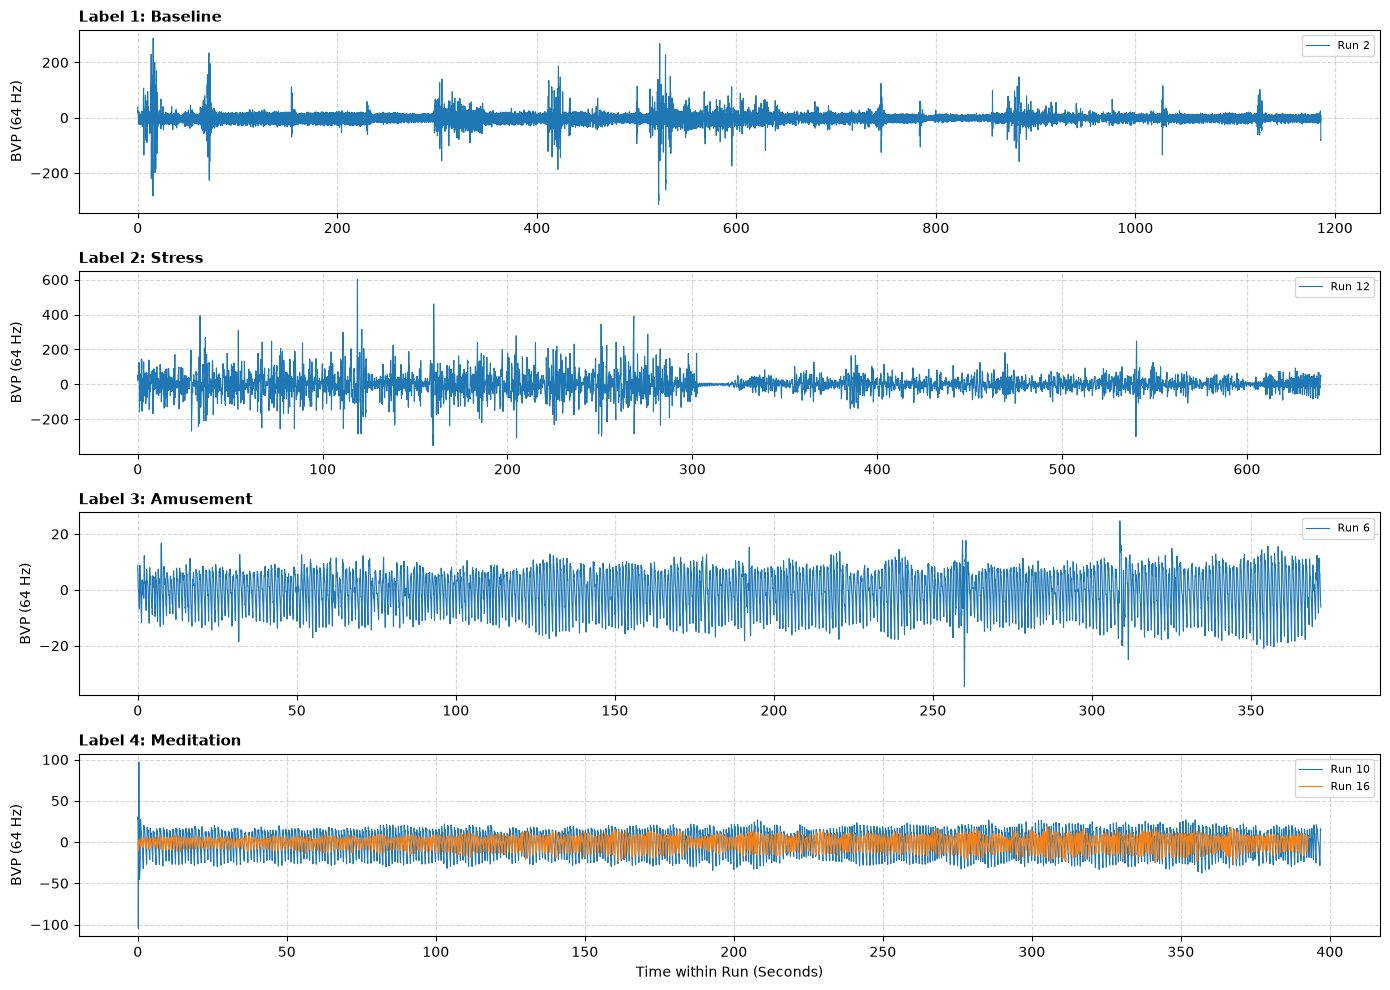

In [11]:
s_raw_runs_df = s_raw_runs_df[~s_raw_runs_df['label'].isin([0, 5, 6, 7])].copy()

# Get unique labels present in the subject data
unique_labels = sorted(s_raw_runs_df['label'].unique())

# Create subplots — one for each label
fig, axes = plt.subplots(
    len(unique_labels), 1, 
    figsize=(14, 2.5 * len(unique_labels)), 
    sharex=False
)

if len(unique_labels) == 1:
    axes = [axes]

# Map label IDs to condition names for clarity
label_names = {
    0: "Transient / Undefined",
    1: "Baseline",
    2: "Stress",
    3: "Amusement",
    4: "Meditation"
}

for ax, lbl in zip(axes, unique_labels):
    label_df = s_raw_runs_df[s_raw_runs_df['label'] == lbl]
    
    # Plot continuous runs for this label
    for run_id, run_group in label_df.groupby('run_id'):
        ax.plot(
            run_group['Seconds'], 
            run_group['BVP'], 
            label=f"Run {run_id}", 
            linewidth=0.8
        )
    
    title_str = label_names.get(lbl, f"Label {lbl}")
    ax.set_title(f"Label {lbl}: {title_str}", fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel("BVP (64 Hz)")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel("Time within Run (Seconds)")
plt.tight_layout()
plt.show()

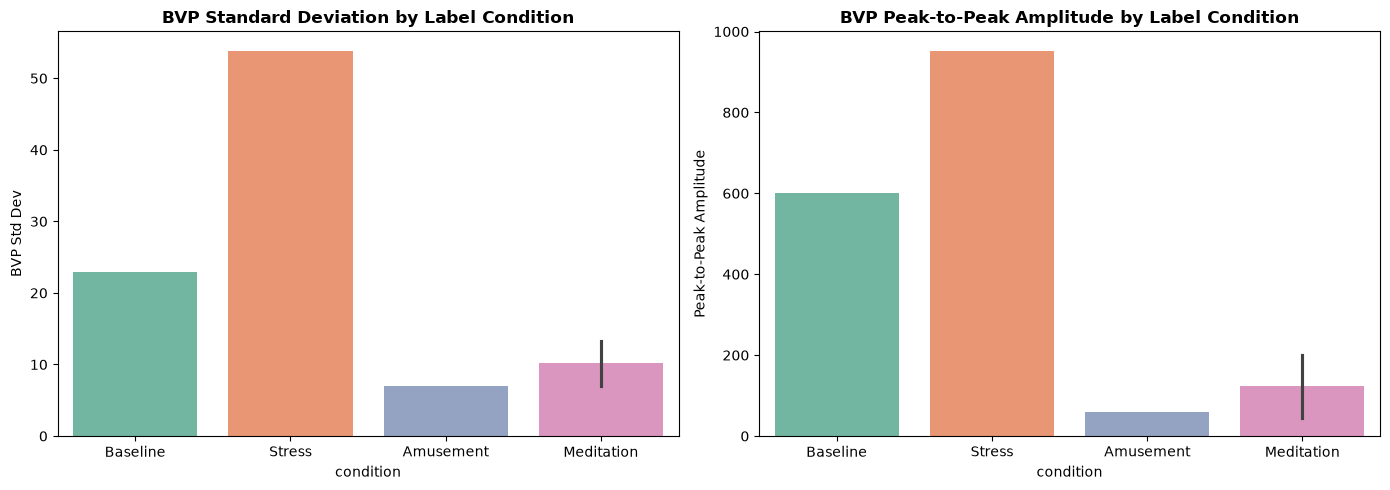

,run_id,label,duration_sec,mean_bvp,std_bvp,min_bvp,max_bvp,peak_to_peak,condition
0,2,1,1185.98438,0.006751,22.865895,-313.46,287.63,601.09,Baseline
1,12,2,639.98438,0.025919,53.869143,-351.94,600.91,952.85,Stress
2,6,3,371.98438,0.004918,7.003539,-34.76,24.72,59.48,Amusement
3,10,4,396.98438,-0.004146,13.282098,-104.43,96.90,201.33,Meditation
4,16,4,392.98438,0.001234,7.055658,-26.25,18.68,44.93,Meditation


In [12]:
# 1. Filter out unwanted labels (0, 5, 6, 7)
valid_runs_df = s_raw_runs_df[~s_raw_runs_df['label'].isin([0, 5, 6, 7])].copy()

# 2. Compute summary metrics per run
summary_list = []
for (lbl, run), group in valid_runs_df.groupby(['label', 'run_id']):
    bvp = group['BVP'].to_numpy()
    summary_list.append({
        'run_id': run,
        'label': lbl,
        'duration_sec': group['Seconds'].max(),
        'mean_bvp': np.mean(bvp),
        'std_bvp': np.std(bvp),
        'min_bvp': np.min(bvp),
        'max_bvp': np.max(bvp),
        'peak_to_peak': np.ptp(bvp)
    })

metrics_df = pd.DataFrame(summary_list)

# Map numeric labels to readable condition names
label_map = {1: 'Baseline', 2: 'Stress', 3: 'Amusement', 4: 'Meditation'}
metrics_df['condition'] = metrics_df['label'].map(label_map)

# 3. Visualize summary metric comparison across labels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot BVP Standard Deviation (Variability)
sns.barplot(
    data=metrics_df, 
    x='condition', 
    y='std_bvp', 
    hue='condition',
    ax=axes[0], 
    palette='Set2'
)
axes[0].set_title('BVP Standard Deviation by Label Condition', fontsize=12, fontweight='bold')
axes[0].set_ylabel('BVP Std Dev')

# Plot BVP Peak-to-Peak Amplitude
sns.barplot(
    data=metrics_df, 
    x='condition', 
    y='peak_to_peak', 
    hue='condition',
    ax=axes[1], 
    palette='Set2'
)
axes[1].set_title('BVP Peak-to-Peak Amplitude by Label Condition', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Peak-to-Peak Amplitude')

plt.tight_layout()
plt.show()

# Display summary metrics table
metrics_df

## Reproducibility Steps

1. Resample to 125 Hz
2. Fourth-order Butterworth low-pass filter at 8 Hz
3. DC offset removal
4. Slice into 10-second windows
5. Per-segment min-max normalization

#### 1. Resample to 125 Hz

#### 2. Fourth-order Butterworth low-pass filter at 8 Hz


In [13]:
TARGET_HZ = 125
CUTOFF_HZ = 8
FILTER_ORDER = 4

filtered_runs = []
for (lbl, run), group_df in s_raw_runs_df.groupby(['label', 'run_id']):
    bvp = group_df['BVP'].to_numpy()

    resampled = DataProcessing.resample_signal(bvp, fs_original=64, fs_target=TARGET_HZ)

    filtered = filter(
        resampled,
        sampling_rate=TARGET_HZ,
        low_cutoff=CUTOFF_HZ,
        order=FILTER_ORDER,
        btype="lowpass",
    )

    out_df = pd.DataFrame({'BVP_filtered': filtered})
    out_df['label'] = lbl
    out_df['run_id'] = run
    out_df = DataProcessing.create_time_df(out_df, sampling_rate=TARGET_HZ)
    filtered_runs.append(out_df)

s_filtered_runs_df = pd.concat(filtered_runs, ignore_index=True)
s_filtered_runs_df

AttributeError: type object 'DataProcessing' has no attribute 'resample_signal'

#### 3. DC offset removal

#### 4. Slice into 10-second windows

#### 5. Per-segment min-max normalization